# **Stacked Charts**


We will focus on visualizing data specifically using stacked charts. You will use SQL queries to extract the necessary data and apply stacked charts to analyze the composition and comparison within the data.


## Objectives


- Visualize the composition of data using stacked charts.

- Compare multiple variables across different categories using stacked charts.

- Analyze trends within stacked chart visualizations.


## Setup: Downloading and Loading the Data
**Install the libraries**


In [1]:
!pip install pandas

In [2]:
!pip install matplotlib


**Download and Load the Data**


To start, download and load the dataset into a `pandas` DataFrame.



### Step 1: Download the dataset


In [3]:
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  4.20MB/s    in 41s     

2026-08-19 08:41:53 (3.70 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]


### Step 2: Import necessary libraries and load the dataset


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Load the data


In [2]:
df = pd.read_csv("survey-data.csv")

### Display the first few rows of the data to understand its structure


In [3]:
df.head()

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Stacked Chart for Composition of Job Satisfaction Across Age Groups


##### 1. Stacked Chart of Median `JobSatPoints_6` and `JobSatPoints_7` for Different Age Groups


Visualize the composition of job satisfaction scores (`JobSatPoints_6` and `JobSatPoints_7`) across various age groups. This will help in understanding the breakdown of satisfaction levels across different demographics.



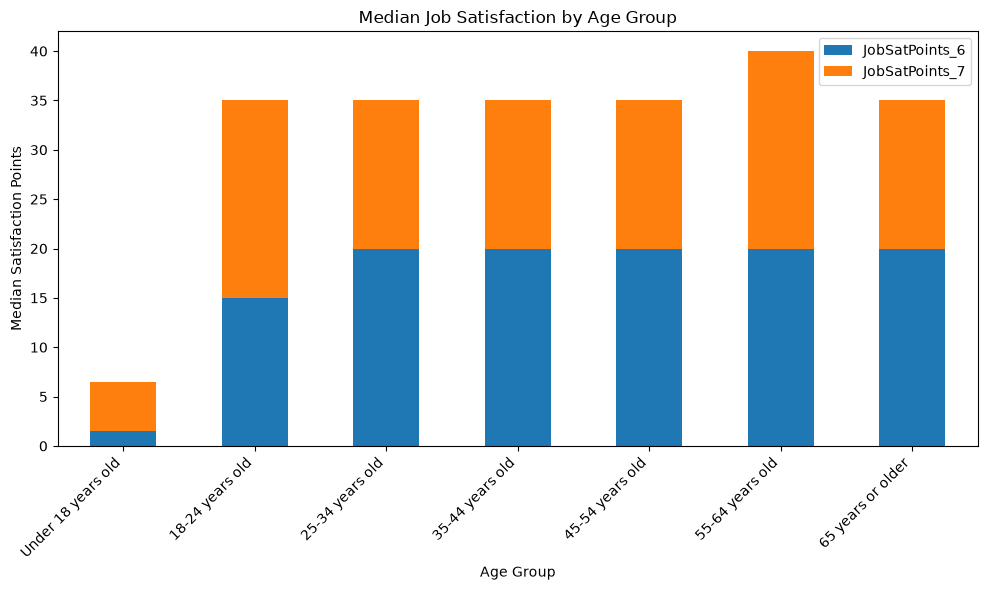

In [13]:
# Median job satisfaction by age group
df["JobSatPoints_6"] = pd.to_numeric(df["JobSatPoints_6"], errors="coerce")
df["JobSatPoints_7"] = pd.to_numeric(df["JobSatPoints_7"], errors="coerce")

age_order = [
    "Under 18 years old", "18-24 years old", "25-34 years old",
    "35-44 years old", "45-54 years old", "55-64 years old",
    "65 years or older"
]

data = df.groupby("Age")[["JobSatPoints_6", "JobSatPoints_7"]].median()
data = data.reindex(age_order).dropna(how="all")

data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Median Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Satisfaction Points")
plt.xticks(rotation=45, ha="right")
plt.legend(["JobSatPoints_6", "JobSatPoints_7"])
plt.tight_layout()
plt.show()

##### Stacked Chart of `JobSatPoints_6` and `JobSatPoints_7` for Employment Status


Create a stacked chart to compare job satisfaction (`JobSatPoints_6` and `JobSatPoints_7`) across different employment statuses. This will show how satisfaction varies by employment type.


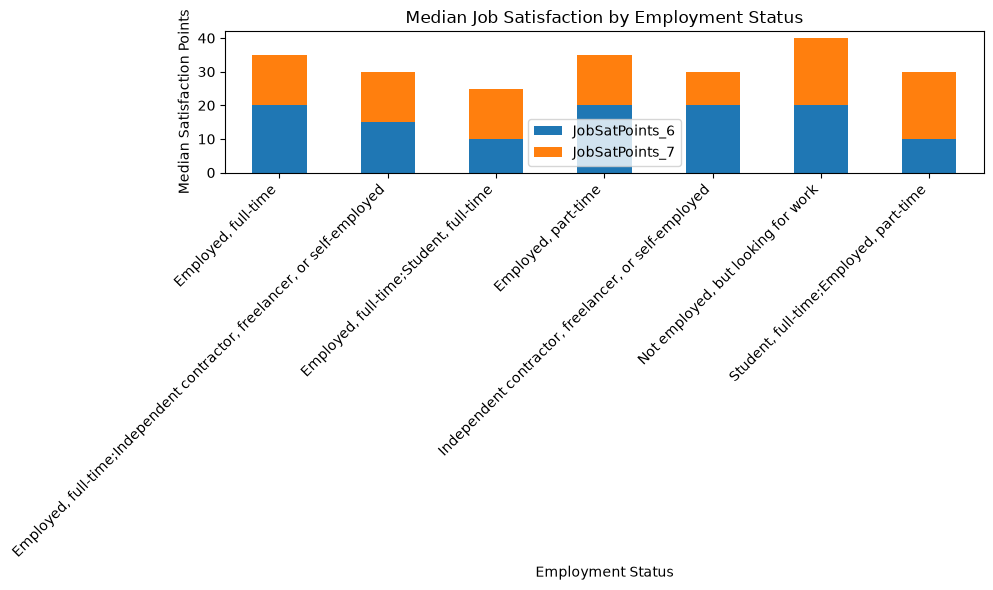

In [14]:
# Median job satisfaction by employment status
data = df.groupby("Employment")[["JobSatPoints_6", "JobSatPoints_7"]].median()
data = data.dropna(how="all").sort_index()

# Keep the chart readable by showing the 8 most common employment categories
common = df["Employment"].value_counts().head(8).index
data = data.loc[data.index.intersection(common)]

data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Median Job Satisfaction by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Median Satisfaction Points")
plt.xticks(rotation=45, ha="right")
plt.legend(["JobSatPoints_6", "JobSatPoints_7"])
plt.tight_layout()
plt.show()

### Stacked Chart for Compensation and Job Satisfaction by Age Group


##### This stacked chart visualizes the composition of compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) specifically for respondents aged 25-34.


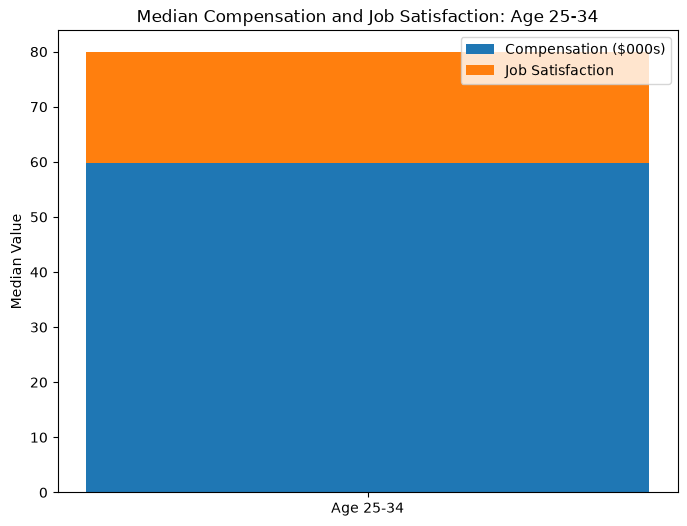

In [5]:
data = df[df["Age"] == "25-34 years old"][["ConvertedCompYearly", "JobSatPoints_6"]].copy()

data["ConvertedCompYearly"] = pd.to_numeric(data["ConvertedCompYearly"], errors="coerce")
data["JobSatPoints_6"] = pd.to_numeric(data["JobSatPoints_6"], errors="coerce")
median_values = data.dropna().median()

plt.figure(figsize=(8, 6))

plt.bar("Age 25-34", median_values["ConvertedCompYearly"]/1000,
        label="Compensation ($000s)")

plt.bar("Age 25-34", median_values["JobSatPoints_6"],
        bottom=median_values["ConvertedCompYearly"]/1000,
        label="Job Satisfaction")

plt.ylabel("Median Value")
plt.title("Median Compensation and Job Satisfaction: Age 25-34")
plt.legend()
plt.show()

##### Stacked Chart of Median Compensation and Job Satisfaction Across Age Group


Compare the median compensation and job satisfaction metrics across different age groups. This helps visualize how compensation and satisfaction levels differ by age.


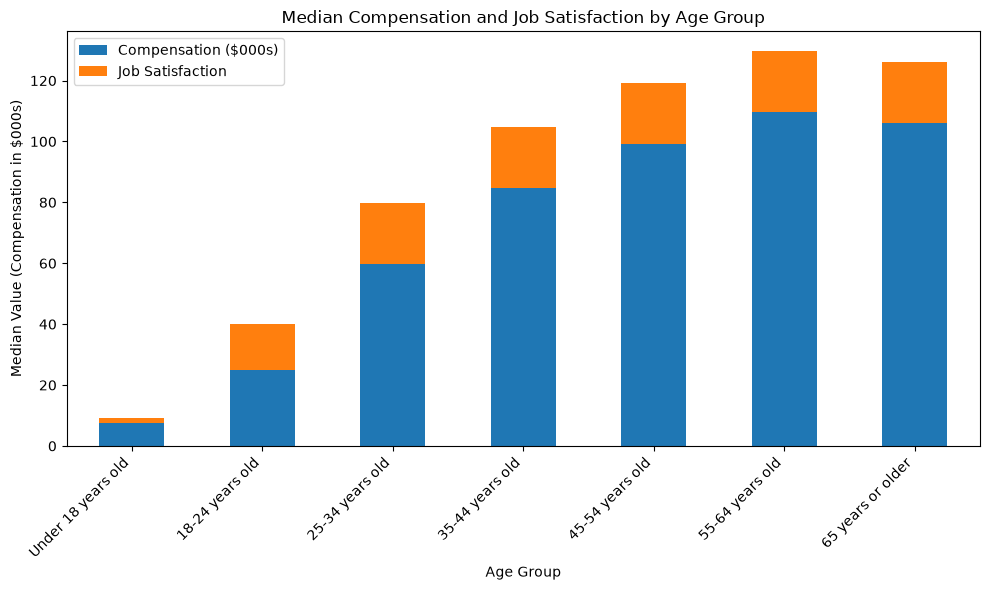

In [16]:
# Median compensation and job satisfaction across age groups
df["ConvertedCompYearly"] = pd.to_numeric(df["ConvertedCompYearly"], errors="coerce")

data = df.groupby("Age")[["ConvertedCompYearly", "JobSatPoints_6"]].median()
data = data.reindex(age_order).dropna(how="all")

# Show compensation in thousands so both measures are easier to read
data["ConvertedCompYearly"] = data["ConvertedCompYearly"] / 1000

data.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Median Compensation and Job Satisfaction by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Median Value (Compensation in $000s)")
plt.xticks(rotation=45, ha="right")
plt.legend(["Compensation ($000s)", "Job Satisfaction"])
plt.tight_layout()
plt.show()

### Comparing Data Using Stacked Charts


##### 1. Stacked Chart of Preferred Databases by Age Group




Visualize the top databases that respondents from different age groups wish to learn. Create a stacked chart to show the proportion of each database in each age group.


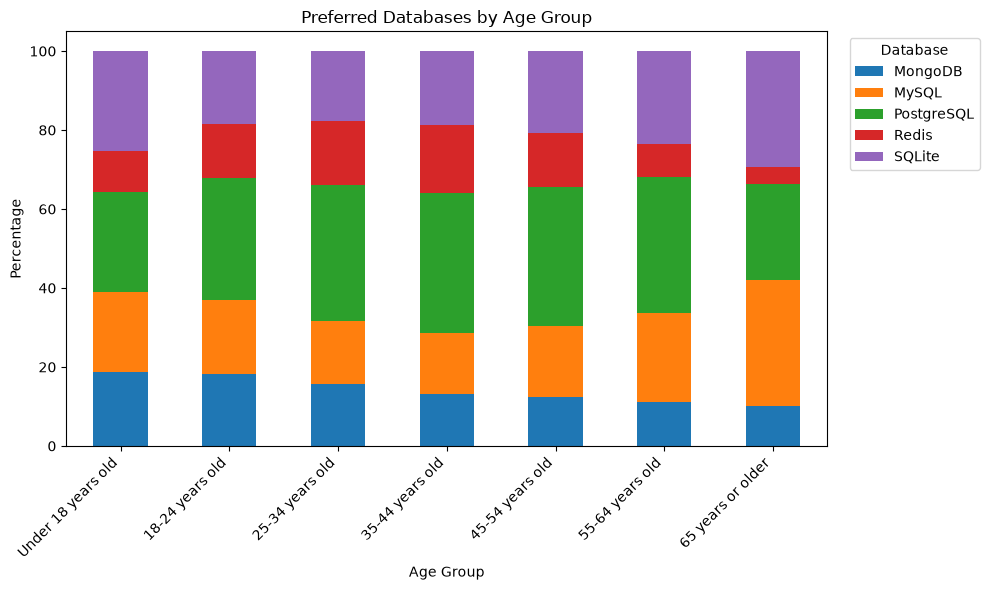

In [18]:
# Preferred databases by age group

db = df[["Age", "DatabaseWantToWorkWith"]].dropna().copy()

# Split multiple database choices
db["DatabaseWantToWorkWith"] = db["DatabaseWantToWorkWith"].str.split(";")
db = db.explode("DatabaseWantToWorkWith").reset_index(drop=True)

# Remove extra spaces
db["DatabaseWantToWorkWith"] = db["DatabaseWantToWorkWith"].str.strip()

# Select top 5 databases
top5 = db["DatabaseWantToWorkWith"].value_counts().head(5).index
db = db[db["DatabaseWantToWorkWith"].isin(top5)].reset_index(drop=True)

# Create percentage table
table = pd.crosstab(
    db["Age"],
    db["DatabaseWantToWorkWith"],
    normalize="index"
) * 100

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

table = table.reindex(age_order).fillna(0)

# Stacked chart
table.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Preferred Databases by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Database", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### 2. Stacked Chart of Employment Type by Job Satisfaction


Analyze the distribution of employment types within each job satisfaction level using a stacked chart. This will provide insights into how employment types are distributed across various satisfaction ratings.


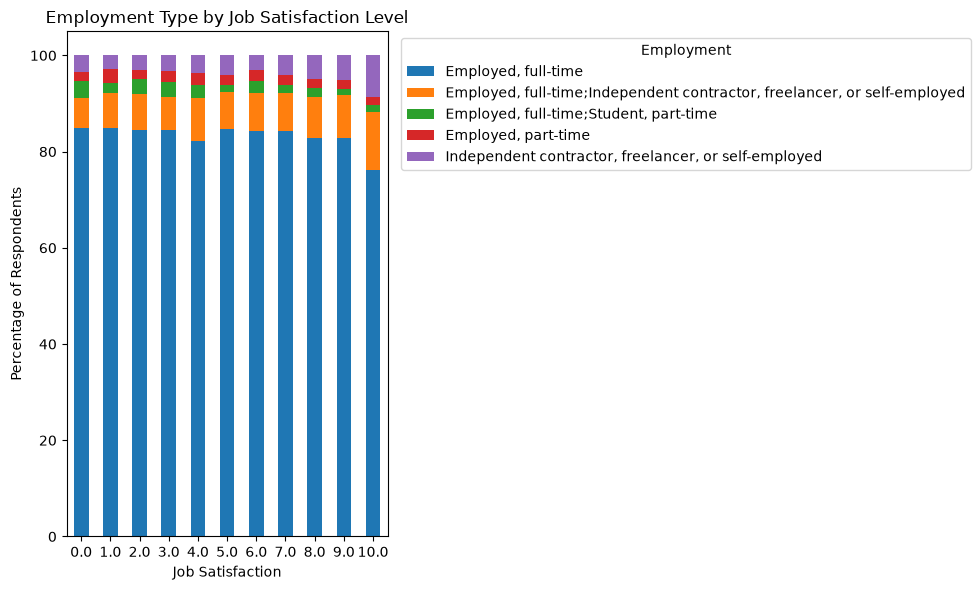

In [19]:
# Employment type by job satisfaction level
data = df[["JobSat", "Employment"]].dropna().copy()
data["JobSat"] = pd.to_numeric(data["JobSat"], errors="coerce")
data = data.dropna()

# Keep the most common employment categories
top_employment = data["Employment"].value_counts().head(5).index
data = data[data["Employment"].isin(top_employment)]

table = pd.crosstab(data["JobSat"], data["Employment"], normalize="index") * 100

table.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Employment Type by Job Satisfaction Level")
plt.xlabel("Job Satisfaction")
plt.ylabel("Percentage of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Employment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Exploring Technology Preferences Using Stacked Charts


##### 1. Stacked Chart for Preferred Programming Languages by Age Group


Analyze how programming language preferences (`LanguageAdmired`) vary across age groups.


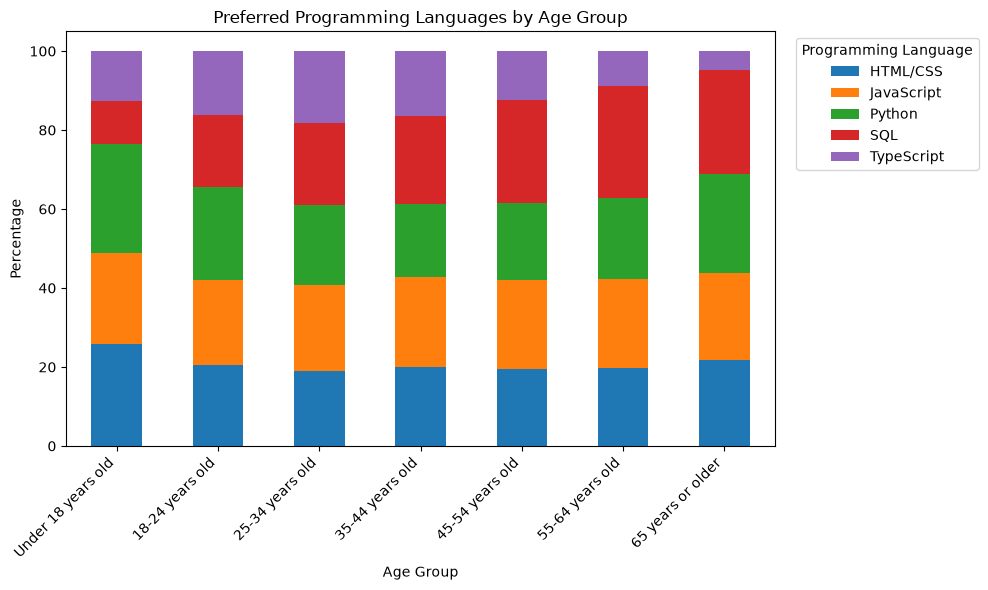

In [20]:
# Preferred programming languages by age group

lang = df[["Age", "LanguageAdmired"]].dropna().copy()

lang["LanguageAdmired"] = lang["LanguageAdmired"].str.split(";")
lang = lang.explode("LanguageAdmired").reset_index(drop=True)
lang["LanguageAdmired"] = lang["LanguageAdmired"].str.strip()

# Select top 5 languages
top5 = lang["LanguageAdmired"].value_counts().head(5).index
lang = lang[lang["LanguageAdmired"].isin(top5)].reset_index(drop=True)

# Create percentage table
table = pd.crosstab(
    lang["Age"],
    lang["LanguageAdmired"],
    normalize="index"
) * 100

age_order = [
    "Under 18 years old",
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

table = table.reindex(age_order).fillna(0)

# Stacked chart
table.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Preferred Programming Languages by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Programming Language", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

##### 2. Stacked Chart for Technology Adoption by Employment Type


Explore how admired platforms (`PlatformAdmired`) differ across employment types (e.g., full-time, freelance)


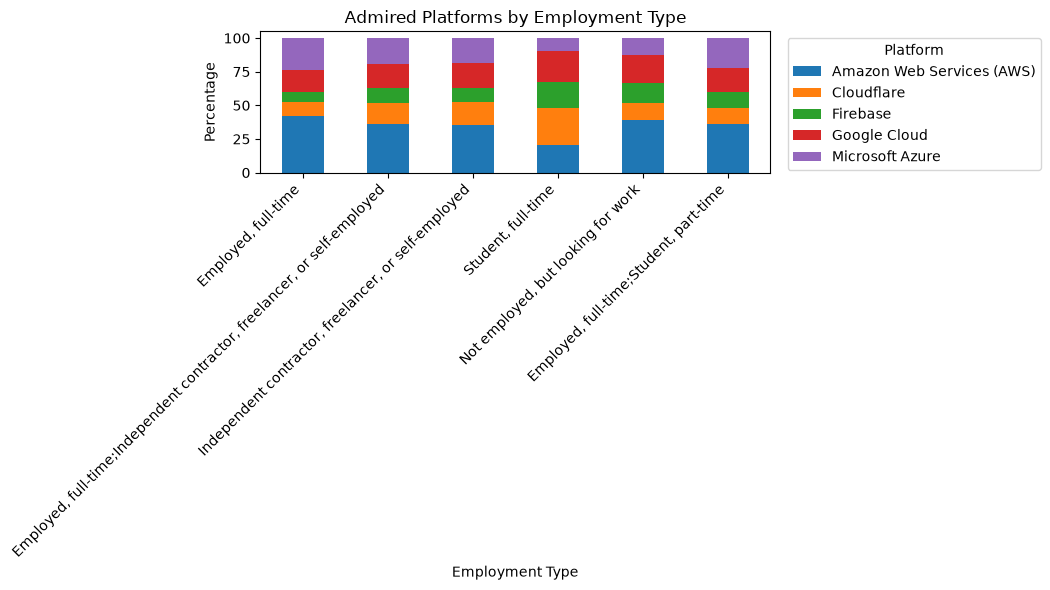

In [7]:
# Admired platforms by employment type

platform = df[["Employment", "PlatformAdmired"]].dropna().copy()

platform["PlatformAdmired"] = platform["PlatformAdmired"].str.split(";")
platform = platform.explode("PlatformAdmired").reset_index(drop=True)
platform["PlatformAdmired"] = platform["PlatformAdmired"].str.strip()

# Select top 5 platforms
top5 = platform["PlatformAdmired"].value_counts().head(5).index
platform = platform[platform["PlatformAdmired"].isin(top5)].reset_index(drop=True)

# Create percentage table
table = pd.crosstab(
    platform["Employment"],
    platform["PlatformAdmired"],
    normalize="index"
) * 100

# Keep the most common employment types
top_employment = platform["Employment"].value_counts().head(6).index
table = table.reindex(top_employment).fillna(0)

# Stacked chart
table.plot(kind="bar", stacked=True, figsize=(10, 6))

plt.title("Admired Platforms by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Platform", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## Summary


- Use stacked charts to analyze the composition of data across categories, such as job satisfaction and compensation by age group.

- Compare data across different dimensions using stacked charts, enhancing your ability to communicate complex relationships in the data.

- Visualize distributions across multiple categories, such as employment type by satisfaction, to gain a deeper understanding of patterns within the dataset.
